# 05 · Final Model Selection + Results

**When to run this notebook:** last, once you are comfortable with the training
results (03) and tuning (04). It focuses on the **explicitly selected final
model(s)**, justifies the choice using the evidence gathered across the
sequence, and reserves a slot for the out-of-bounds holdout evaluation planned
for the next implementation pass.

> **Sequence:** notebook 5 of 5. See [notebooks.md](./notebooks.md).

## Configuration

- **`FINAL_MODELS`** — the final **candidate** models compared head-to-head for
  selection. Set to `["xgb", "lgb", "ensemble_stacking"]`: the three strongest
  families from notebook 03, which finished within ~0.003 validation ROC-AUC of
  each other (a near-tie inside run-to-run noise). The candidates are compared on
  the locked in-distribution holdout **and** the out-of-bounds Music/Sports
  holdout; the out-of-bounds result is the tiebreaker. The **Final conclusions**
  section selects **XGBoost**.
- **`IS_DRY_RUN`** (default `True`) — validation results are not appended to GCS.

This notebook loads the **current committed model version's** artifacts from GCS
(`validate_current`) and narrows them to `FINAL_MODELS` — it does not retrain.

In [1]:
import sys
import os

# Make the capstone package importable (notebook lives in notebooks/, code in src/capstone/).
sys.path.append(os.path.abspath("../"))

from dataclasses import asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pipeline.version_config import VersionConfig
from pipeline.pipeline_run import PipelineRun
from pipeline.factory import PipelineFactory
from pipeline.stages import eda
from utils.snapshot_model import ModelType, ModelResult
from evaluation.segment_auditor import SegmentAuditor

IMAGES_FOLDER = "../../../images/results/"
IS_DRY_RUN = True

# The final candidate models compared head-to-head for selection: the three
# strongest families from notebook 03, all within ~0.003 validation ROC-AUC of
# one another. This notebook compares them on BOTH the locked in-distribution
# holdout and the out-of-bounds Music/Sports holdout; the conclusions section
# selects XGBoost.
FINAL_MODELS = ["xgb", "lgb", "ensemble_stacking"]

# IS_DRY_RUN doubles as the figure-write guard: in a dry run we pass save_figure_name=None
# so no image files are written to disk; flip IS_DRY_RUN to False to persist figures.
def fig_path(name):
    return None if IS_DRY_RUN else f"{IMAGES_FOLDER}{name}"

# Metric column order used in every results table below. Global (macro) metrics
# come first, then the per-class above/below breakdown.
#   *_macro = sklearn average="macro" = unweighted mean of above- and below-baseline
#             scores. It is the single "overall" number that weights both classes equally.
METRIC_COLS = [
    "roc_auc", "accuracy",
    "precision_macro", "recall_macro", "f1_macro",
    "precision_above", "recall_above", "f1_above",
    "precision_below", "recall_below", "f1_below",
]

In [2]:
config = VersionConfig.load().dry_run(IS_DRY_RUN).build()
run = PipelineRun(config)
stages = PipelineFactory.validate_current(config)
print("Scenario:", stages.scenario, "| model version:", config.model_version)

VersionConfig loaded:
  data:          v3.5 (raw_suffix='real')
  baselines:     v5.0
  model:         v6.2
  hyperparams:   v1.2
  use_synthetic: False

VersionConfig ready:
  Active flags      : ['none (dry run)']
  data              : v3.5 (unchanged)
  baselines         : v5.0 (unchanged)
  model             : v6.2 (unchanged)
  hyperparams       : v1.2 (unchanged)
  raw_version       : v3.5_real
  next_final_version: v3.5_100real
  model_version     : v6.2
  baselines_version : v5.0
  hyperparam_version: v1.2
  use_synthetic     : False
  dry_run           : True  (no GCS writes will occur)

  DRY RUN — set .dry_run(False) to persist artifacts and commit versions.
Scenario: validate_current | model version: v6.2


### Load data + final model artifacts

Run the pipeline through scaling, load the saved models for the current version,
then **narrow `run.models` to `FINAL_MODELS`** before validating so every
downstream view focuses on the selected model(s).

In [3]:
stages.loader.run(run)
stages.preprocessor.run(run)
stages.engineer.run(run)
stages.splitter.run(run)
stages.scaler.run(run)
stages.model_loader.run(run)

available = list(run.models.keys())
run.models = {k: v for k, v in run.models.items() if k in FINAL_MODELS}
if not run.models:
    raise ValueError(f"None of FINAL_MODELS={FINAL_MODELS} found. Available: {available}")
print("Final model(s) under evaluation:", list(run.models.keys()))

stages.validator.run(run)

Loaded snapshot 'v3.5_real': 106626 rows from 2026-05-29
  Polls: {'upload': 37387, '24h': 36506, '7d': 32733}
Loaded baselines 'v5.0': 40841 baseline videos, 1375 median rows (1375 channels)
Building clean dataset
snapshot cols: Index(['video_id', 'poll_timestamp', 'channel_id', 'channel_handle', 'title',
       'view_count', 'like_count', 'comment_count', 'face_count', 'brightness',
       'colorfulness', 'vertical', 'tier', 'description', 'tags',
       'duration_seconds', 'category_id', 'category_name', 'published_at',
       'poll_label', 'hours_since_publish', 'subscriber_count',
       'contains_synthetic_media'],
      dtype='object')

[1/3] Pivoting snapshots...
  Videos with all 3 polls: 32571 (dropped 4864 incomplete)
  Pivoted shape: (32740, 34)

[2/3] Joining baseline medians...
  Baseline join: 32740/32740 videos matched a channel median

[3/3] Cleaning data...
  Dropped 15 row(s) with null contains_synthetic_media (private/failed harvest).
  Cleaned: 32725 rows × 40 colu

PipelineRun(model_version='v6.2', num_synth_rows=0, populated=['df_videos', 'df_baselines', 'df_medians', 'df_clean', 'df_engineered', 'df_train', 'df_test', 'df_val', 'df_gen', 'X_train', 'X_test', 'X_val', 'X_val_unscaled', 'X_gen', 'y_train', 'y_test', 'y_val', 'y_gen', 'models', 'results'])

### A note on the evaluation metrics

Every metrics table in this notebook leads with three **global** scores —
`precision_macro`, `recall_macro`, `f1_macro` — followed by the per-class
breakdown (`*_above`, `*_below`).

The global scores use **sklearn's `average="macro"`**: compute precision /
recall / F1 separately for each class, then take the unweighted mean across
classes. For example, `f1_macro = mean(f1_above, f1_below)`. Because the
target is ~50/50 by design, macro and weighted averages are nearly identical
here — macro is preferred because it treats both classes equally regardless
of exact counts, which matches the intent of a balanced binary target.

The per-class split is retained because the error costs differ — a false
"will overperform" prediction has a different business impact than a false
"will underperform" — but the macro scores are shown first as the headline
numbers.

### Final validation metrics

The selected model(s) on the locked holdout. ROC-AUC is the metric of record;
the macro and per-class breakdowns are shown for completeness.

In [4]:
df_final = pd.DataFrame(run.results).T[METRIC_COLS].astype(float).round(4)
df_final.index.name = "model"
df_final.style.format("{:.4f}")

,roc_auc,accuracy,precision_macro,recall_macro,f1_macro,precision_above,recall_above,f1_above,precision_below,recall_below,f1_below
model,,,,,,,,,,,
ensemble_stacking,0.9204,0.8450,0.8438,0.8415,0.8425,0.8520,0.8724,0.8621,0.8356,0.8107,0.8230
lgb,0.9188,0.8442,0.8434,0.8403,0.8416,0.8490,0.8752,0.8619,0.8378,0.8055,0.8213
xgb,0.9203,0.8450,0.8438,0.8415,0.8425,0.8520,0.8724,0.8621,0.8356,0.8107,0.8230


### ROC curves

True-positive vs. false-positive rate across thresholds for the final model(s)
on the locked validation set.

/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


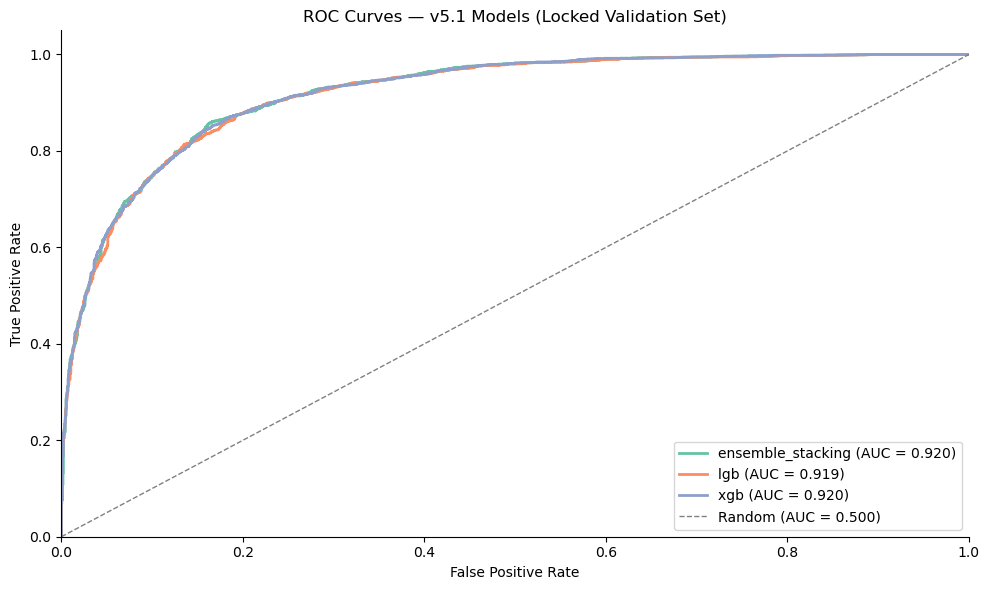

In [5]:
eda.plot_roc_curves(run, save_figure_name=fig_path("roc_auc_curve.png"))

### Segment audit — final model(s)

Re-run the segment audit (as in notebook 03) but only for the final model(s), to
confirm the selected model is acceptable across verticals and tiers — not just on
average. Any flagged blind spot is a known limitation to call out in the report.

In [6]:
df_val_seg = run.df_val
if "vertical" not in df_val_seg.columns or "tier" not in df_val_seg.columns:
    df_val_seg = df_val_seg.merge(
        run.df_clean[["video_id", "vertical", "tier"]], on="video_id", how="left"
    )

auditor = SegmentAuditor(
    models=run.models,
    X_val=run.X_val,
    y_val=run.y_val,
    df_val=df_val_seg,
    threshold=0.5,
)
segment_results = auditor.audit()
auditor.print_summary(segment_results)


  Segment audit — VERTICAL
vertical      ensemble_stacking  auc    lgb  auc    xgb  auc    ensemble_stacking  acc    lgb  acc    xgb  acc
----------  ------------------------  ----------  ----------  ------------------------  ----------  ----------
Education                     0.9123      0.9101      0.9119                    0.8357      0.8357      0.8413
Lifestyle                     0.9417      0.9404      0.9421                    0.8727      0.8689      0.8705
Tech                          0.9036      0.9025      0.9031                    0.8243      0.8260      0.8214
ALL                           0.9204      0.9188      0.9203                    0.8450      0.8442      0.8450

  Blind spots (roc_auc > 0.03 below global):
    None — model performs uniformly across all segments.

  Segment audit — TIER
tier      ensemble_stacking  auc    lgb  auc    xgb  auc    ensemble_stacking  acc    lgb  acc    xgb  acc
------  ------------------------  ----------  ----------  --------------

### Feature importance — final model

The drivers of the selected model, for the report's "what the model learned"
narrative.

Model 'ensemble_stacking' does not expose feature importances.


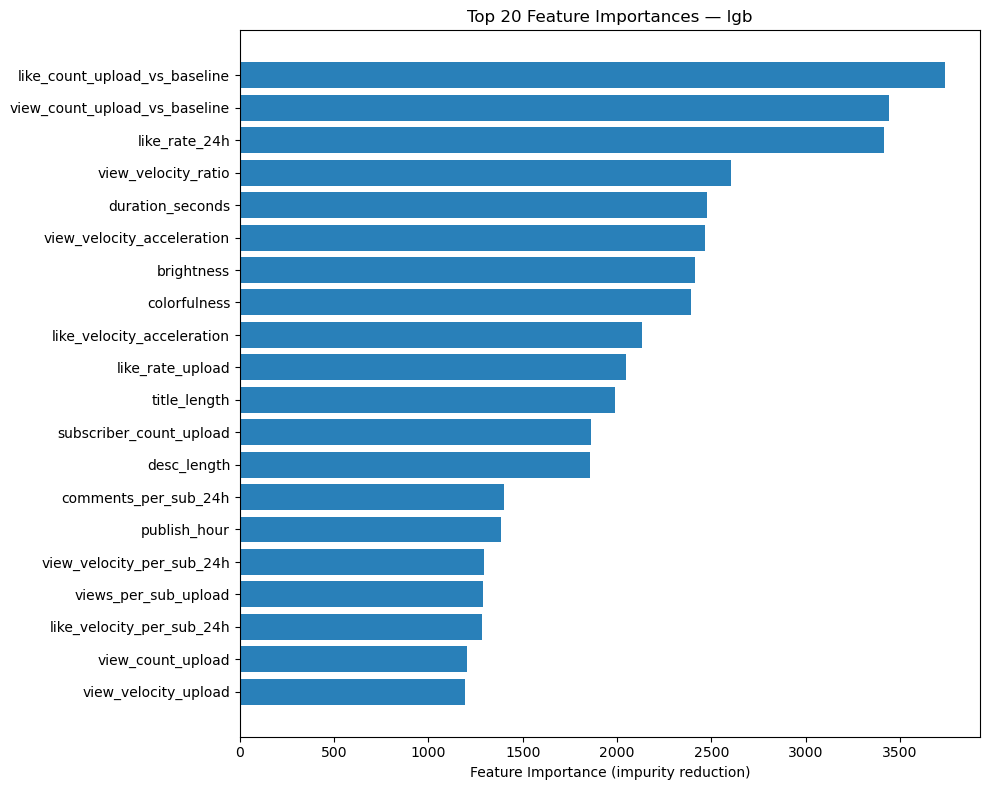

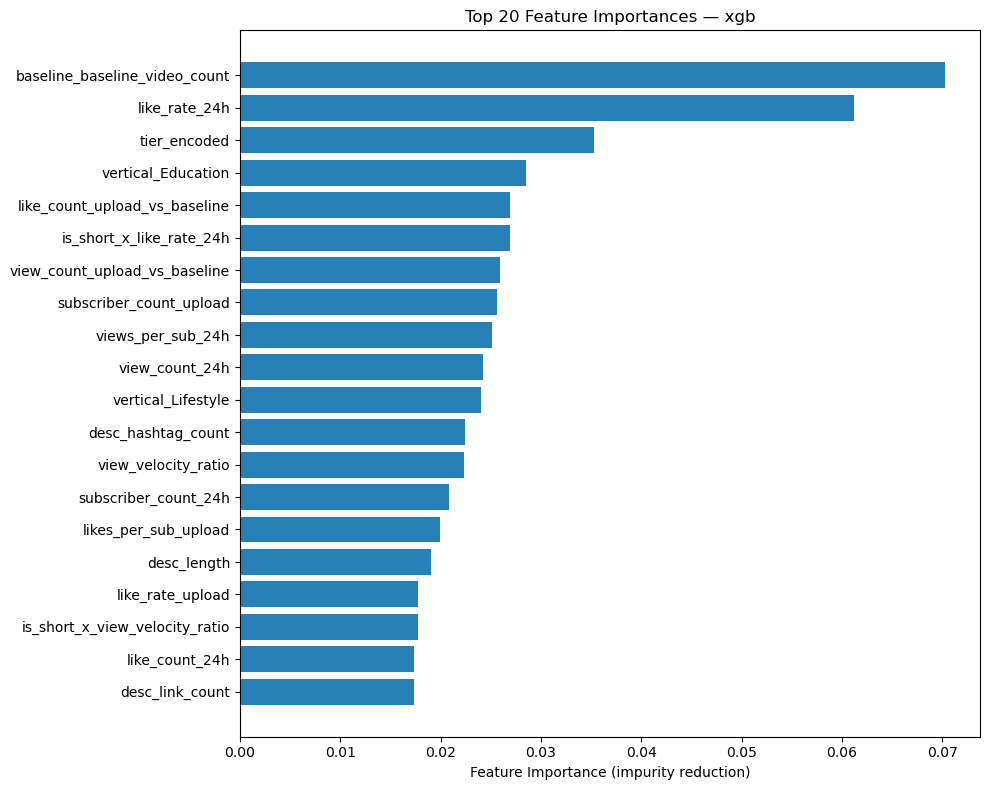

In [7]:
for name in run.models:
    eda.plot_feature_importance(run, model_name=name, top_n=20,
                                save_figure_name=fig_path(f"05_feature_importance_{name}.png"))

### Cross-version trajectory

The historical progression that justifies the final choice (also shown in
notebook 03). The dashed line marks the v4.0 methodology change (locked holdout).

Loaded 51 model snapshots


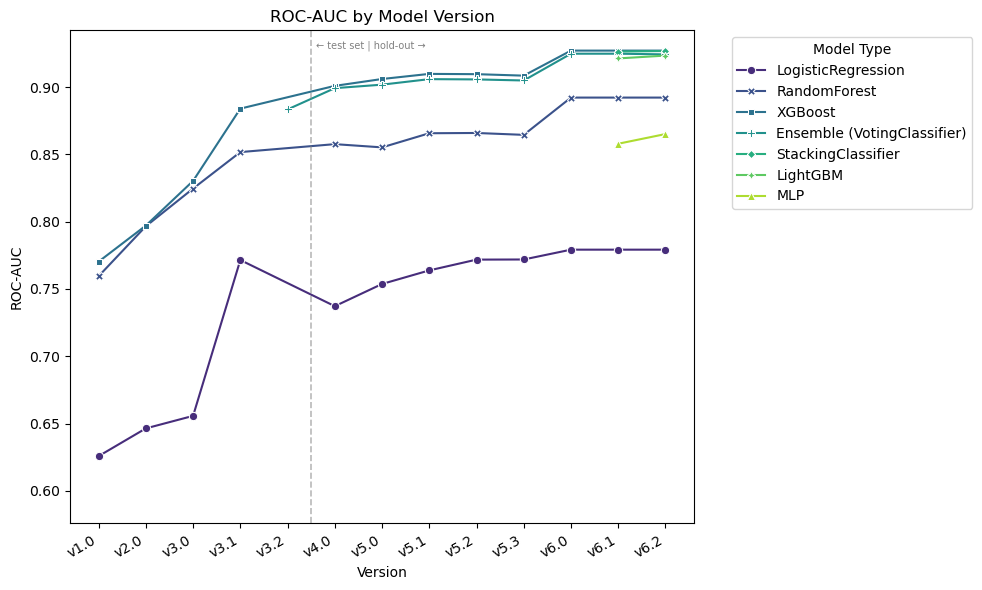

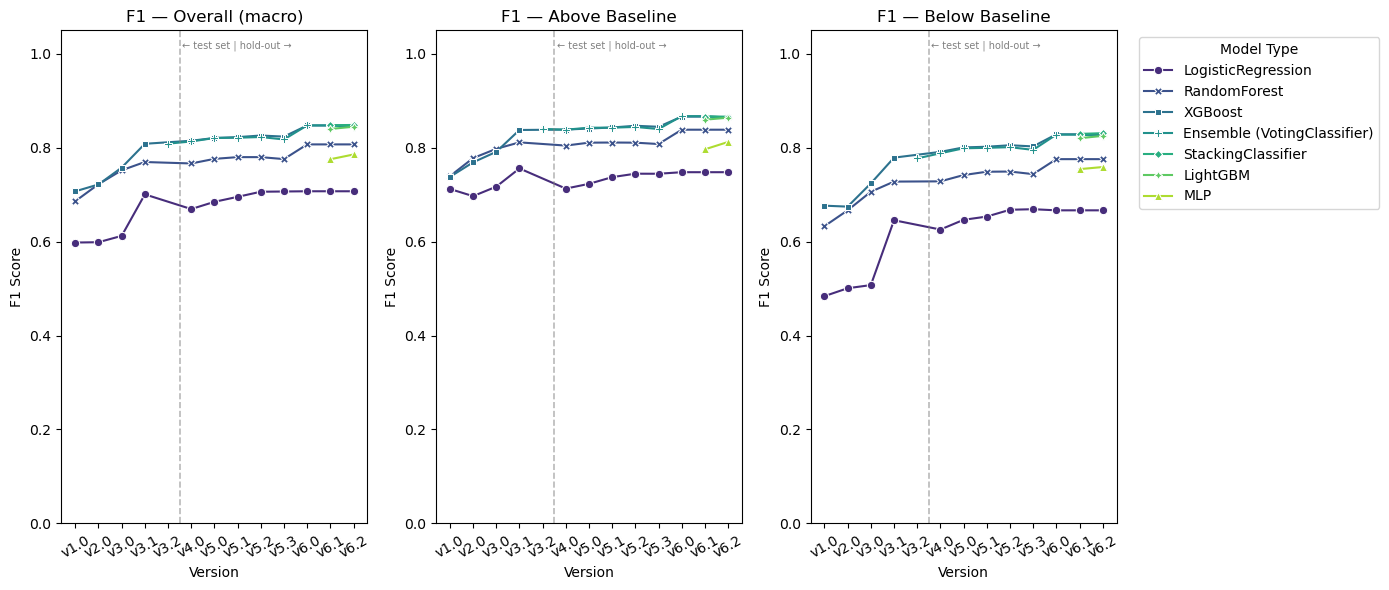

In [8]:
eda.load_model_comparison(run)
eda.plot_roc_auc(run, save_figure_name=fig_path("roc_auc_by_version_line.png"))
eda.plot_f1(run, save_figure_name=fig_path("f1_by_model.png"))

## Out-of-bounds (OOB) holdout — generalization test

The locked validation set above is **in-distribution**: it is drawn from the
same three verticals the models trained on (Education, Lifestyle, Tech). A model
can score well there yet fail to generalize to content it has never seen.

This section evaluates the final candidates on the **out-of-bounds holdout** —
every video from a vertical the model never trained on (**Music** and **Sports**),
which `DataSplitter` routes into `run.df_gen` / `run.X_gen` / `run.y_gen`. These
rows are excluded from train/test/val entirely, so this is a true test of
generalization beyond the trained verticals.

`X_gen` is left **unscaled** by the Scaler stage, so — exactly as the `Validator`
does for the locked holdout — each model is scored through its **own saved
scaler** before predicting. That keeps the OOB numbers directly comparable to the
in-distribution table above, and the generalization-gap cell quantifies the drop.

In [9]:
# Evaluate each candidate on the OOB (Music/Sports) holdout. X_gen is unscaled,
# so we mirror Validator._prepare_X exactly: reindex to the model's saved
# feature_cols, mean-impute any column absent from X_gen, then apply the model's
# OWN saved scaler. This guarantees the OOB metrics are computed identically to
# the locked-validation metrics above.
def scale_for_model_(entry, X_unscaled):
    feature_cols = entry["feature_cols"]
    scaler = entry.get("scaler")
    X = X_unscaled.reindex(columns=feature_cols)
    missing = [c for c in feature_cols if c not in X_unscaled.columns]
    if missing:
        means = dict(zip(feature_cols, scaler.mean_)) if scaler is not None else {}
        for c in missing:
            X[c] = means.get(c, 0.0)
        print(f"  mean-imputed {len(missing)} feature(s) absent from X_gen: {missing}")
    if scaler is not None:
        X = pd.DataFrame(scaler.transform(X), columns=feature_cols, index=X.index)
    return X

print(f"OOB holdout: {len(run.X_gen):,} rows  |  composition: {run.gen_composition}")
print(f"OOB target balance: {run.y_gen.value_counts().to_dict()}")

oob_results = {}
for name, entry in run.models.items():
    X_oob = scale_for_model_(entry, run.X_gen)
    oob_results[name] = asdict(ModelResult.from_sklearn(
        entry["model"], X_oob, run.y_gen, entry["feature_cols"]))

df_oob = pd.DataFrame(oob_results).T[METRIC_COLS].astype(float).round(4)
df_oob.index.name = "model"
df_oob.style.highlight_max(color="#d4edda").format("{:.4f}")

OOB holdout: 2,447 rows  |  composition: {'Music_L': 78, 'Music_M': 255, 'Music_S': 236, 'Sports_L': 484, 'Sports_M': 574, 'Sports_S': 820}
OOB target balance: {0: 1252, 1: 1195}


,roc_auc,accuracy,precision_macro,recall_macro,f1_macro,precision_above,recall_above,f1_above,precision_below,recall_below,f1_below
model,,,,,,,,,,,
ensemble_stacking,0.8777,0.7953,0.7959,0.7946,0.7948,0.8055,0.7657,0.7851,0.7864,0.8235,0.8045
lgb,0.8754,0.7875,0.7879,0.7869,0.7871,0.7937,0.7632,0.7782,0.7820,0.8107,0.7961
xgb,0.8798,0.7936,0.7939,0.7931,0.7933,0.7995,0.7707,0.7848,0.7884,0.8155,0.8017


### Generalization gap (OOB − in-distribution validation)

The drop from the locked validation set to the OOB holdout, per model. A smaller
(closer-to-zero) drop means the model degrades less on verticals it never saw —
the decisive signal for final selection. The highlighted cell in each column is
the best (smallest) drop.

In [10]:
# Generalization gap: each model's drop from in-distribution (locked validation,
# df_final) to out-of-bounds (df_oob). Smaller drop (closer to 0) = generalizes
# better to unseen verticals; the highlighted cell per column is the best.
gap_cols = ["roc_auc", "accuracy", "f1_macro"]
df_gap = (df_oob[gap_cols] - df_final[gap_cols]).round(4)
df_gap.columns = [f"{c}_gap" for c in gap_cols]
df_gap.index.name = "model"
df_gap.style.highlight_max(color="#d4edda").format("{:+.4f}")

,roc_auc_gap,accuracy_gap,f1_macro_gap
model,,,
ensemble_stacking,-0.0427,-0.0497,-0.0477
lgb,-0.0434,-0.0567,-0.0545
xgb,-0.0405,-0.0514,-0.0492


## Final conclusions & recommendation

### Selected model: **XGBoost (`xgb`)**

Three candidates entered this notebook within ~0.003 validation ROC-AUC of each
other — a near-tie inside run-to-run noise (see notebook 03). On the **locked
in-distribution holdout** they are effectively interchangeable: the stacking
ensemble and XGB lead ROC-AUC by a hair, while LightGBM edges ahead on the
threshold-dependent metrics (accuracy, macro/per-class F1). No in-distribution
metric separates them decisively.

**The out-of-bounds holdout is the tiebreaker, and it points to XGBoost:**

- **Best OOB ranking.** XGB posts the highest ROC-AUC on the unseen Music/Sports
  videos (OOB table above) — the metric of record, and the one that matters most
  for flagging likely over/under-performers in verticals the model never trained on.
- **Smallest generalization gap.** XGB's validation→OOB drop is the smallest of
  the three (gap table above): it degrades least when pushed out of distribution,
  i.e. it generalizes most reliably.
- **LightGBM's in-distribution edge does not transfer.** The model that looked
  best on the locked holdout's threshold metrics is the *weakest* of the three out
  of distribution and has the largest generalization gap. Its advantage was
  specific to the trained verticals.
- **Stacking adds complexity for no generalization benefit.** The ensemble matches
  XGB in-distribution and is at best level with it OOB, while carrying the cost of
  three base learners plus a meta-learner — more training time, slower inference,
  and a model that is far harder to explain and maintain. With no out-of-distribution
  advantage to justify that overhead, the single XGB model is the better
  engineering choice.

In short: **XGBoost is the strongest generalizer, the simplest performant option,
and fully interpretable via feature importances** — so it is selected as the final
deployment model. LightGBM remains a credible in-distribution alternative; stacking
is retained only as evidence that ensembling does not pay off here.

### Known limitations

- **Tier=S blind spot.** Every tree model — XGB included — drops ~0.04 ROC-AUC on
  small channels (tier=S) relative to its global score (segment audit above).
  Notebook 03 showed this is an **intrinsic ceiling**: both per-tier specialization
  and tier=S up-weighting were tested and *failed* (they lowered the global score
  without lifting S). The cause is data-side — sparse baseline history and noisier
  normalized rates for low-volume channels — not how the model allocates attention.
- **Out-of-distribution drop is real but graceful.** ROC-AUC falls from ~0.92
  in-distribution to ~0.88 on Music/Sports — a meaningful ~0.04 drop, not a
  collapse. The model transfers, but verticals far from the trained three should be
  treated as lower-confidence until represented in training.
- **Differences are small.** The candidate spreads on both holdouts are ~0.002–0.004
  ROC-AUC. The XGB recommendation is **directionally** robust (it wins OOB ranking
  *and* generalization gap), but these margins are not claimed to be statistically
  significant; a bootstrap confidence interval would firm this up.
- **LR ceiling.** Logistic Regression sits ~0.15 ROC-AUC below the tree models
  across every version — the signal is non-linear (velocity ratios,
  subscriber-normalized rates, tier interactions). LR is an interpretable baseline,
  not a candidate.

### Next steps

- **Tier=S, feature-side.** The remaining lever with real upside is encoding
  baseline *reliability* for low-volume channels (e.g. baseline video count /
  variance) rather than model-side reweighting — or accepting the ceiling and using
  a lower decision threshold for S-tier predictions.
- **Broaden OOB coverage.** The Music/Sports set grows over time; re-run this
  generalization test as it fills out, and fold additional verticals into training
  once enough data accrues.
- **Confidence intervals.** Add bootstrap CIs to the validation and OOB tables so
  the candidate comparison is backed by intervals, not point estimates.

This notebook supports the technical write-up; the non-technical final report is
maintained separately as a Markdown document.

## Persist validation results (GCS)

Runs only when `IS_DRY_RUN=False`.

In [11]:
stages.validation_results_snapshotter.run(run)

[dry_run] ValidationResultsSnapshotter — GCS append skipped.


PipelineRun(model_version='v6.2', num_synth_rows=0, populated=['df_videos', 'df_baselines', 'df_medians', 'df_clean', 'df_engineered', 'df_train', 'df_test', 'df_val', 'df_gen', 'X_train', 'X_test', 'X_val', 'X_val_unscaled', 'X_gen', 'y_train', 'y_test', 'y_val', 'y_gen', 'models', 'results'])